In [1]:
#random forest implementation here 
#using the LOSO method which I have heard is the standard for PAMPA2 

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils import shuffle

In [4]:
#first we need to take snapshots of the each data set with the sliding window 
def sliding_window_features(df, window_size=100, step=50):
    feature_cols = df.columns.drop("activityID")
    X, y = [], []
    
    for start in range(0, len(df) - window_size + 1, step):
        window = df.iloc[start:start + window_size]
      
        label = window["activityID"].mode()[0]
      
        features = []
        for col in feature_cols:
            features += [
                window[col].mean(),
                window[col].std(),
                window[col].min(),
                window[col].max(),
            ]
        
        X.append(features)
        y.append(label)
    
    return np.array(X), np.array(y)
  

In [5]:
import os
os.makedirs(r"/content/CPEN355_FinalProject/preprocessing/data", exist_ok=True)

for i in range(1, 9):
    globals()[f"data_{i}"] = pd.read_pickle(rf"/content/CPEN355_FinalProject/preprocessing/data/data_{i}.pkl")

X_all = {}
y_all = {}

for i in range(1, 9):
    df = globals()[f"data_{i}"]
    X, y = sliding_window_features(df, window_size=100, step=50)
    X_all[i] = X
    y_all[i] = y


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import shuffle


results = {}


global_y_true = []
global_y_pred = []


for test_subject in range(1,9):
    x_train = np.vstack([X_all[i] for i in range(1,9) if i != test_subject])
    y_train = np.concatenate([y_all[i] for i in range(1,9) if i != test_subject])
    x_train, y_train = shuffle(x_train, y_train, random_state=50)

    model = RandomForestClassifier(n_estimators=100, random_state=50, n_jobs=-1)
    model.fit(x_train, y_train)
    y_pred = model.predict(X_all[test_subject])


    global_y_true.extend(y_all[test_subject])
    global_y_pred.extend(y_pred)

    acc = accuracy_score(y_all[test_subject], y_pred)
    mac_f1 = f1_score(y_all[test_subject], y_pred, average='macro')
    wt_f1 = f1_score(y_all[test_subject], y_pred, average='weighted')

    results[test_subject] = {
        "accuracy": acc,
        "macro_f1": mac_f1,
        "weighted_f1": wt_f1,
        "report": classification_report(y_all[test_subject], y_pred)
    }

    print(f"Subject {test_subject} (test) — Accuracy: {acc:.4f} | Macro F1: {mac_f1:.4f}")

print(f"\nMean LOSO Accuracy: {np.mean([r['accuracy'] for r in results.values()]):.4f}")

Subject 1 (test) — Accuracy: 0.8006 | Macro F1: 0.7787


Subject 2 (test) — Accuracy: 0.9494 | Macro F1: 0.9493


Subject 3 (test) — Accuracy: 0.9556 | Macro F1: 0.9564


Subject 4 (test) — Accuracy: 0.9540 | Macro F1: 0.9499


Subject 5 (test) — Accuracy: 0.9529 | Macro F1: 0.9472


Subject 6 (test) — Accuracy: 0.9292 | Macro F1: 0.9281


Subject 7 (test) — Accuracy: 0.9656 | Macro F1: 0.9607


Subject 8 (test) — Accuracy: 0.9666 | Macro F1: 0.9622

Mean LOSO Accuracy: 0.9342


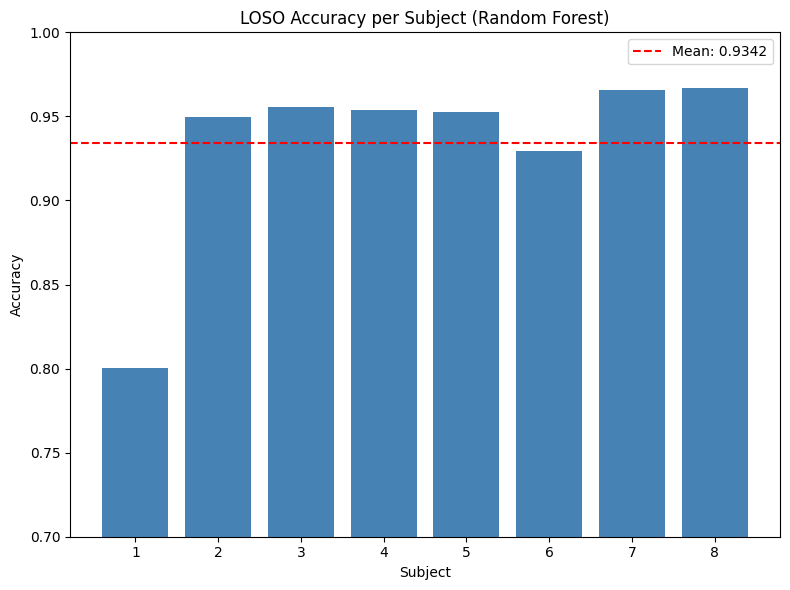

In [7]:
subjects = [1,2,3,4,5,6,7,8]
acc = [0.8006, 0.9494, 0.9556, 0.9540, 0.9529, 0.9292,0.9656, 0.9666]
plt.figure(figsize=(8,6))
plt.bar(subjects, acc, color='steelblue')
plt.axhline(y=np.mean(acc), color='red', linestyle='--', label=f'Mean: {np.mean(acc):.4f}')
plt.xlabel('Subject')
plt.ylabel('Accuracy')
plt.title('LOSO Accuracy per Subject (Random Forest)')
plt.ylim(0.7, 1.0)
plt.legend()
plt.tight_layout()
plt.savefig('loso_accuracy.png', dpi=150)
plt.show()

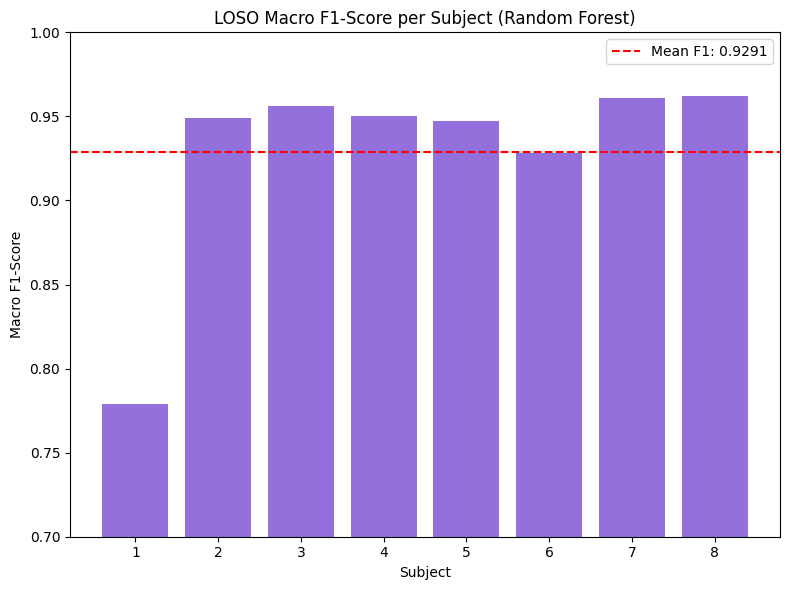

Global Macro F1-Score:    0.9345
Global Weighted F1-Score: 0.9350

              precision    recall  f1-score   support

           1       0.98      0.98      0.98       348
           2       0.94      0.83      0.88       338
           3       0.86      0.90      0.88       345
           4       1.00      0.98      0.99       412
          12       0.91      0.95      0.93       216
          13       0.98      0.93      0.95       190
          16       0.91      0.95      0.93       320
          17       0.91      0.94      0.93       433

    accuracy                           0.94      2602
   macro avg       0.94      0.93      0.93      2602
weighted avg       0.94      0.94      0.93      2602



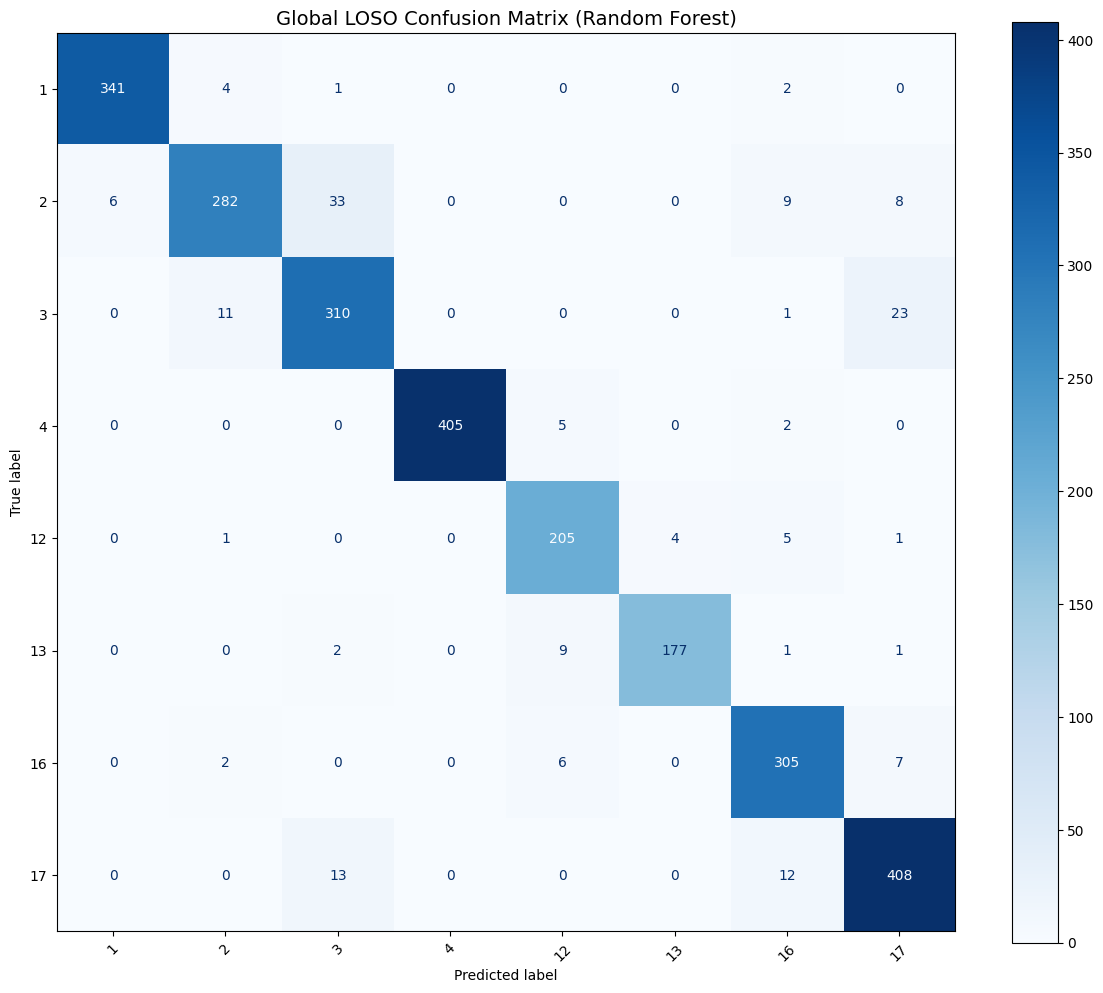

In [8]:
# --- Plot Macro F1 Score per subject ---
subjects  = list(results.keys())
macro_f1s = [results[s]['macro_f1'] for s in subjects]

plt.figure(figsize=(8, 6))
plt.bar(subjects, macro_f1s, color='mediumpurple')
plt.axhline(y=np.mean(macro_f1s), color='red', linestyle='--', label=f'Mean F1: {np.mean(macro_f1s):.4f}')

plt.xlabel('Subject')
plt.ylabel('Macro F1-Score')
plt.title('LOSO Macro F1-Score per Subject (Random Forest)')
plt.ylim(0.7, 1.0)
plt.legend()
plt.tight_layout()
plt.savefig('loso_f1_rf.png', dpi=150)
plt.show()

# --- Global Evaluation Metrics ---
# Calculate Macro and Weighted F1 Score globally
macro_f1 = f1_score(global_y_true, global_y_pred, average='macro')
weighted_f1 = f1_score(global_y_true, global_y_pred, average='weighted')

print(f"Global Macro F1-Score:    {macro_f1:.4f}")
print(f"Global Weighted F1-Score: {weighted_f1:.4f}\n")

# Extract unique classes directly from the data for labels
classes = np.unique(global_y_true)
print(classification_report(global_y_true, global_y_pred, target_names=classes.astype(str)))

# --- Plot the Global Confusion Matrix ---
cm = confusion_matrix(global_y_true, global_y_pred)
fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes.astype(str))
disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)

plt.title('Global LOSO Confusion Matrix (Random Forest)', fontsize=14)
plt.tight_layout()
plt.savefig('global_confusion_matrix_rf.png', dpi=150)
plt.show()